# IBM watsonx.governance evaluation of Tool Calling Agent developed using Langgraph

This notebook demonstrates how to use the Tool call Syntactic Accuracy evaluator from IBM watsonx.governance for governing your applications right in your development environment.

The sample app shown here is an Agentic RAG example which uses the tools get_current_weather, fetch_stock_price to respond to the user queries. 

### Install the dependencies

In [ ]:
%pip install --quiet "ibm-watsonx-gov[agentic, visualization]" "ibm-watsonx-ai>=1.3.1,<1.4.0"

In [ ]:
%pip install --quiet "langchain-ibm>=0.3.10,<1.1.0" "langchain-community>=0.3.30,<1.0.0" "langgraph>=0.2.23,<1.2.0"

In [ ]:
%pip install --quiet "setuptools==70.0.0"

**Note**: If you encounter any Torch-related attribute errors while setting up the evaluator, try resolving them by running the cell below to uninstall Torch. This step is required when running in Watson Studio.

In [ ]:
# %pip uninstall -y torch

### Runtime-specific Python library updates and rebuilds

#### For Runtime 24.1
If you are running the notebook in the Runtime 24.1 environment, uncomment the below cell. It force-reinstalls certain Python packages to ensure they are rebuilt or upgraded for compatibility with NumPy 2.x.

In [ ]:
# %pip install --quiet --upgrade --force-reinstall --no-cache-dir "ibm-agent-analytics<0.6.0" chromadb tensorflow "transformers<4.54.0" numexpr bottleneck opencv-python pyarrow-hotfix

#### For Runtime 25.1
If you are running the notebook in Runtime 25.1 environment, uncomment the below cells. The following cells installs `pysqlite3-binary` and configures it as the default `sqlite3`, overriding the older system-managed version. 

In [ ]:
# %pip install --upgrade --force-reinstall --no-cache-dir pysqlite3-binary

In [ ]:
# import sys
# import pysqlite3

# # replace stdlib sqlite3 with pysqlite3
# sys.modules["sqlite3"] = pysqlite3

### Accept the credentials
The following code snippet ensures that specific environment variables are set without being hardcoded in the script. It does so by prompting the user for input only if the variables are not already set.

The environment variables need to be set are:

1. **WATSONX_PROJECT_ID:** This is required to use the watsonx.ai. You can either create a new project by following this [documentation](https://dataplatform.cloud.ibm.com/docs/content/wsj/getting-started/projects.html?context=wx&audience=wdp#create-a-project), or use an existing one. To find the project ID, navigate to the **Manage** section of the chosen project and copy it from the **General** details.
 
For watsonx.governance Cloud
1. **WATSONX_APIKEY:** This is required for IBM watsonx.governance capabilities. Your Cloud API key can be generated by going to the [**Users** section of the Cloud console](https://cloud.ibm.com/iam#/users). From that page, click your name, scroll down to the **API Keys** section, and click **Create an IBM Cloud API key**. Give your key a name and click **Create**, then copy the created key and paste it below.
2. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one watsonx.governance instance.
3. **WATSONX_REGION** [Optional]: Set if you are using IBM watsonx.governance as a service in a regional data center other than default **Dallas (us-south), in Texas US**. Supported region values are "us-south", "eu-de", "au-syd", "ca-tor", "jp-tok", "eu-gb".

For watsonx.governance OnPrem
1. **WATSONX_URL** : The CPD cluster URL.
2. **WATSONX_USERNAME** : The CPD username.
3. **WATSONX_PASSWORD** [Optional] : The CPD password.
4. **WATSONX_APIKEY** [Optional] : The CPD API key. Either WATSONX_APIKEY or WATSONX_PASSWORD is required for CPD authentication.
5. **WATSONX_VERSION** : The version of CPD.
6. **WATSONX_DISABLE_SSL** [Optional]: Set to true if you want to disable SSL.
7. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one datamart


In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("WATSONX_PROJECT_ID")

# For Cloud
_set_env("WATSONX_APIKEY")
# _set_env("WATSONX_REGION") # To specify region
# _set_env("WXG_SERVICE_INSTANCE_ID") # To specify a governance instance id if more than one exist

# For watsonx.governance on-prem
# _set_env("WATSONX_URL")
# _set_env("WATSONX_USERNAME")
# _set_env("WATSONX_APIKEY")
# _set_env("WATSONX_PASSWORD") # Only one of apikey and password should be specified.
# _set_env("WATSONX_VERSION")
# _set_env("WATSONX_DISABLE_SSL")  # Set to true if you want to disable SSL
# _set_env("WXG_SERVICE_INSTANCE_ID") # To specify a governance instance id if more than one exist

### Set up the Watsonx LLM model
In this section, we initialize the ChatWatsonx from the langchain_ibm package to use IBM's Granite language model (granite-3-2b-instruct) for text generation.
Environment variables are used to securely access the IBM Watsonx platform:

- WATSONX_URL: Base URL for the Watsonx service.
- WATSONX_APIKEY: API key for authentication.
- WATSONX_PROJECT_ID: ID of the Watsonx project to scope resources

In [ ]:
from langchain_ibm import ChatWatsonx
import os

llm = ChatWatsonx(
    model_id="meta-llama/llama-3-2-11b-vision-instruct",
    url=os.getenv("WATSONX_URL", "https://us-south.ml.cloud.ibm.com"),
    # Uncomment the following lines if using watsonx.governance on-prem
    # username=os.getenv("WATSONX_USERNAME"),
    # password=os.getenv("WATSONX_PASSWORD"), # Only one of api_key or password is needed
    # instance_id="openshift",
    # version=os.getenv("WATSONX_VERSION"),
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=os.getenv("WATSONX_PROJECT_ID"),
    params={
        "decoding_method": "greedy",
        "temperature": 0,
        "min_new_tokens": 5,
        "max_new_tokens": 250,
        "stop_sequences": ["Human:", "Observation:"],
    },
)

### Defining Tools for the Agent
This cell sets up custom tools that the agent can call during execution. Each tool wraps a specific Python function and provides a structured interface for interaction within the graph

In [ ]:
from langchain.tools import tool
from enum import Enum
import random

class City(str, Enum):
    barcelona = "Barcelona"
    delhi = "Delhi"
    new_york = "New York"
    tel_aviv = "Tel Aviv"


def get_weather(city: City) -> dict:
    """Returns the weather in Celsius for a given city.
    
    Args:
         city: A given city name. Allowed values are: Barcelona, Delhi, New York, Tel Aviv.

    Returns:
         The weather in the given city in celsius."""
    mock_data = {
        City.barcelona: {
            "temperature_celsius": 23,
            "description": "Partly cloudy",
            "humidity": 60
        },
        City.delhi: {
            "temperature_celsius": 35,
            "description": "Hot and dry",
            "humidity": 25
        },
        City.new_york: {
            "temperature_celsius": 18,
            "description": "Rainy",
            "humidity": 75
        },
        City.tel_aviv: {
            "temperature_celsius": 26,
            "description": "Sunny",
            "humidity": 55
        }
    }

    return {"city": city.value, **mock_data[city]}
    
def fetch_stock_price(symbol: str, date:str) -> str:
    """Fetch the current stock price for a given symbol."""
    # Simulate API call
    # Generate a realistic price (between $1 and $1000)
    base_price = random.uniform(1, 1000)
    fluctuation = random.uniform(-0.05, 0.05)  # -5% to +5%
    price = round(base_price * (1 + fluctuation), 2)
    return f"The current price of {symbol} is ${price:.2f}"

tools = [fetch_stock_price, get_weather]

### Binding the Language Model with Tool Specifications

In [4]:
llm_with_tools = llm.bind_tools(tools)

### Set up the State

In [5]:
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from typing import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        input_text (str): 
            The user's raw input query or question. 
        record_id (Optional[str]): 
            Unique identifier for the record.            
        generated_text (Optional[str]): 
            The final output generated by the LLM after processing all contexts.
        tool_calls (list):
            The list of tools invoked for a user query
        messages (list):
            List of messages required for the LLM
    """
    messages: list #List of messages required for the LLM
    input_text: str #The user's raw input query or question
    tool_calls: list #The list of tools invoked for a user query
    record_id: str #Unique identifier for the record.
    generated_text: str #The final output generated by the LLM after processing

#### Initialise the evaluator

In [ ]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator

evaluator = AgenticEvaluator()

### Set up LLM Judge for metrics evaluation

To evaluate the Tool Call Relevance Metric and Tool Call Parameter Accuracy Metric, an LLM must be used as the judge. To enable this, you need to specify the model provider, model name, and provide the necessary credentials.

To use LLM judge to evaluate a metric you need to add the details of the `llm_judge` when creating the metric object. For example:

```python
# Define LLM Judge using watsonx.ai
llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-3-70b-instruct",
        project_id="<PROJECT_ID>",
    )
)

# Defining LLM Judge using OpenAI
llm_judge = LLMJudge(
    model=OpenAIFoundationModel(
        model_id="gpt-4o-mini",
    )
)

# Specify the LLM judge when initializing the metric
@evaluator.evaluate_tool_call_parameter_accuracy(
    configuration=AgenticAIConfiguration(**tool_call_metric_config),
    metrics=[ToolCallParameterAccuracyMetric(llm_judge=llm_judge)],
)

### Build your langgraph application

#### Define LLM Agent Node

Define the logic for invoking the agent within a LangGraph node. It takes the current GraphState and RunnableConfig as input. It invokes the `llm_with_tools ` with the user's input text.

Extracts the tools used during the agent's reasoning process.
Formats the tool usage into a structured list for further analysis or visualization.

Returns the list of tools used, the raw response messages, and a placeholder for generated text.

The `llm_agent` node defined below is decorated with IBM watsonx.governance evaluators: `evaluate_tool_call_accuracy` to measure the syntactic correctness of the tool call, `evaluate_tool_call_relevance` to determine whether the tool call made by the LLM agent correctly addresses the user’s immediate request as the appropriate next step in the conversation, and `evaluate_tool_call_parameter_accuracy` to assess whether all parameter values in a tool call are directly supported by the conversation history or the tool specifications. The accuracy score ranges from `0` to `1`, with values closer to `1` indicating higher accuracy and values closer to `0` indicating lower accuracy. This node reads the user query from the `input_text` attribute from the application state and writes the response into the `tool_calls` attribute and the AIMessage response to the `messages` and set back to the application state.

User can specify the evaluators to be computed after the graph invocation by specifying flag `compute_real_time` set to False.

In [7]:
from ibm_watsonx_gov.config import AgenticAIConfiguration
from langgraph.config import RunnableConfig

In [ ]:
from ibm_watsonx_gov.entities.llm_judge import LLMJudge
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel

llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-2-11b-vision-instruct",
        project_id=os.getenv("WATSONX_PROJECT_ID"),
    )
)

In [ ]:
import json
from ibm_watsonx_gov.metrics import ToolCallRelevanceMetric, ToolCallParameterAccuracyMetric

tool_call_metric_config={
    "question_field": "input_text", 
    "tool_calls_field":"tool_calls",
    "tools":tools
}

@evaluator.evaluate_tool_call_relevance(configuration=AgenticAIConfiguration(**tool_call_metric_config), metrics=[ToolCallRelevanceMetric(llm_judge=llm_judge)], compute_real_time=False)
@evaluator.evaluate_tool_call_parameter_accuracy(configuration=AgenticAIConfiguration(**tool_call_metric_config), metrics=[ToolCallParameterAccuracyMetric(llm_judge=llm_judge)], compute_real_time=False)
@evaluator.evaluate_tool_call_accuracy(configuration=AgenticAIConfiguration(**tool_call_metric_config), compute_real_time=False)
def llm_agent(state: GraphState, config: RunnableConfig):
    
    user_query = state["input_text"]
    response = llm_with_tools.invoke([HumanMessage(user_query)])

    return {
        "messages": [response],
        "tool_calls": response
    }

### Tool Condition Function
- The tools_condition function evaluates the agent's response and determines the next step in the LangGraph workflow based on whether the LLM agent's most recent response includes a tool call.

In [10]:
def tools_condition(state: GraphState, config: RunnableConfig) -> str:
    last_message = state["messages"][-1]
    # If the agent wants to call a tool, go to tools node
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "Has Tools"
    # Otherwise, we're done
    else:
        return "No Tools"

### Define Answer generation node
This node generates the final answer based on the tool execution results, if available; otherwise, it returns a default response.

In [11]:
def generate_response(state: GraphState, config: RunnableConfig) -> dict:
    tool_results = "\n".join(
        [msg.content for msg in state["messages"] if isinstance(msg, ToolMessage)]
    )
    if not tool_results:
        tool_results = "I'm sorry, but the agent couldn't process your query. Please try rephrasing or providing more details so I can better assist you."
    return {
        "messages": [AIMessage(content=f"Final Answer:\n{tool_results}")],
        "generated_text": tool_results
    }

#### Assemble your application

**Note:** If you encounter an issue while importing ToolNode from langgraph, please force install langgraph using the command `pip install --upgrade --force-reinstall "langgraph>=0.3.34,<0.4.0"`

In [12]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode


graph = StateGraph(GraphState)

graph.add_node("LLM Agent", llm_agent)
graph.add_node("Generate Response", generate_response)
graph.add_node("Tools", ToolNode(tools))

graph.set_entry_point("LLM Agent")
graph.add_conditional_edges(
    "LLM Agent",
    tools_condition,
    {"Has Tools": "Tools", "No Tools": "Generate Response"}
)
graph.add_edge("Tools", "Generate Response")
graph.add_edge("Generate Response", END)

# Compile the graph
rag_app = graph.compile()


#### Display the graph

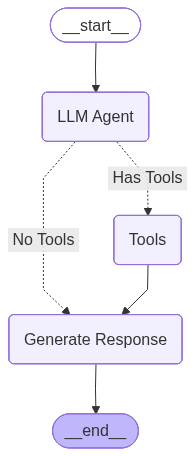

In [13]:
from langchain_core.runnables.graph import MermaidDrawMethod

image = rag_app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

from IPython.display import Image, display
display(Image(data=image))

### Do a single invocation

Now the application is invoked for a single row of data.

#### Evaluator Integration
1. `evaluator.start_run()`: Begins tracking this specific invocation. 

2. `evaluator.end_run()`: Marks the end of the evaluation run. All metrics will now be captured and logged.

In [14]:
evaluator.start_run()

In [15]:
result = rag_app.invoke({"input_text": "What’s the weather today"})

In [16]:
evaluator.end_run()

### Prepare the app results

In [17]:
result = evaluator.get_result()

In [18]:
display(result.to_df())

message_id  Generate Response.latency  \
0  eb1167b367a9c3787c65c1e582e2e662                     0.0243   

   LLM Agent.latency  Tools.latency  message.cost  message.duration  \
0             1.4202         0.0299        0.0001            1.7878   

   message.input_token_count  message.output_token_count  
0                      412.0                        25.0

In [19]:
result.get_aggregated_metrics_results(node_name="LLM Agent")

[{'name': 'latency',
  'display_name': 'Latency',
  'value_type': 'numeric',
  'value': 1.4202,
  'group': 'performance',
  'thresholds': [],
  'min': 1.4202,
  'max': 1.4202,
  'count': 1,
  'node_name': 'LLM Agent',
  'applies_to': 'node',
  'individual_results': [{'name': 'latency',
    'display_name': 'Latency',
    'value': 1.4202,
    'group': 'performance',
    'applies_to': 'node',
    'message_id': 'eb1167b367a9c3787c65c1e582e2e662',
    'conversation_id': 'eb1167b367a9c3787c65c1e582e2e662',
    'node_name': 'LLM Agent',
    'execution_count': 1,
    'execution_order': 1}]}]

### Invoke the graph on multiple rows

IBM watsonx.governance also supports evaluation of Agentic Applications using batch invocation. The following DataFrame contains sample questions that will be used to demonstrate this capability.

In [20]:
import pandas as pd

question_bank_df = pd.read_csv("https://raw.githubusercontent.com/IBM/ibm-watsonx-gov/refs/heads/samples/notebooks/data/agentic/watsonx_governance_tool_call_data.csv")
question_bank_df

input_text
Loading ITables v2.2.5 from the init_notebook_mode cell... (need help?)


#### Execute Batch Invocation

In [21]:
def rate_limit_handling(inputs, max_retries=5, chunk_size=2):
    """
    Call rag_app.batch safely with rate-limit handling.
    """
    results = []
    for i in range(0, len(inputs), chunk_size):
        chunk = inputs[i:i + chunk_size]
        attempt = 0
        while attempt < max_retries:
            try:
                results.extend(rag_app.batch(chunk))
                break  
            except Exception as e:
                if e.status_code == 429:
                    wait_time = 2 ** attempt  
                    print(f"Rate limit hit, waiting {wait_time}s before retry...")
                    time.sleep(wait_time)
                    attempt += 1
                else:
                    raise
        else:
            raise Exception("Max retries exceeded for batch call")
    return results


In [22]:
evaluator.start_run()
records = question_bank_df.to_dict("records")
result =  rate_limit_handling(records)
evaluator.end_run()

In [23]:
result_df = pd.DataFrame(result)
input_data = result_df[["input_text"]] # Add the columns which should be part of the application metric results
eval_result = evaluator.get_result()
metric_result = eval_result.to_df()
result_with_data=pd.concat([input_data, metric_result], axis=1)

display(result_with_data)

input_text  \
0  What's the weather forecast for AAPL stock today?   
1             Is it sunny for Tesla stock right now?   
2                      What's the weather in London?   
3                    Get me the current stock price    
4                     What's the stock doing today?    
5               What's the weather like in New York?   

                         message_id  Generate Response.latency  \
0  3c49d76fcfc6e62585940927468ff53d                     0.0016   
1  4d2b9deb1beb37117d41e602eece328b                     0.0012   
2  50f244556f25e2a25a92118719c78df4                     0.0011   
3  5487ce1eaf19922ad9b8a714e61a441c                     0.0009   
4  d67e55fd642bfa42aef9c00b8a64c1b9                     0.0009   
5  e005b86051ef1922fe43c49e149818d1                     0.0010   

   LLM Agent.latency  Tools.latency  message.cost  message.duration  \
0             0.8611         0.0086        0.0001            0.8784   
1             1.1890            NaN        0.0001            1.1935   
2             0.9905            NaN        0.0001            0.9991   
3             1.0234            NaN        0.0001            1.0331   
4             1.2331         0.0033        0.0001            1.2415   
5             0.7223            NaN        0.0001            0.7273   

   message.input_token_count  message.output_token_count  
0                      415.0                        24.0  
1                      413.0                        26.0  
2                      417.0                         6.0  
3                      418.0                         6.0  
4                      414.0                        42.0  
5                      413.0                         6.0

In [24]:
result_with_data=pd.concat([metric_result], axis=1)
display(result_with_data)

message_id  Generate Response.latency  \
0  3c49d76fcfc6e62585940927468ff53d                     0.0016   
1  4d2b9deb1beb37117d41e602eece328b                     0.0012   
2  50f244556f25e2a25a92118719c78df4                     0.0011   
3  5487ce1eaf19922ad9b8a714e61a441c                     0.0009   
4  d67e55fd642bfa42aef9c00b8a64c1b9                     0.0009   
5  e005b86051ef1922fe43c49e149818d1                     0.0010   

   LLM Agent.latency  Tools.latency  message.cost  message.duration  \
0             0.8611         0.0086        0.0001            0.8784   
1             1.1890            NaN        0.0001            1.1935   
2             0.9905            NaN        0.0001            0.9991   
3             1.0234            NaN        0.0001            1.0331   
4             1.2331         0.0033        0.0001            1.2415   
5             0.7223            NaN        0.0001            0.7273   

   message.input_token_count  message.output_token_count  
0                      415.0                        24.0  
1                      413.0                        26.0  
2                      417.0                         6.0  
3                      418.0                         6.0  
4                      414.0                        42.0  
5                      413.0                         6.0

In [25]:
eval_result.get_aggregated_metrics_results(node_name="LLM Agent")

[{'name': 'latency',
  'display_name': 'Latency',
  'value_type': 'numeric',
  'value': 1.0032,
  'group': 'performance',
  'thresholds': [],
  'min': 0.7223,
  'max': 1.2331,
  'percentiles': {'25': 0.89345,
   '50': 1.00695,
   '75': 1.1476000000000002,
   '90': 1.2110500000000002,
   '95': 1.222075,
   '99': 1.230895},
  'count': 6,
  'node_name': 'LLM Agent',
  'applies_to': 'node',
  'individual_results': [{'name': 'latency',
    'display_name': 'Latency',
    'value': 0.9905,
    'group': 'performance',
    'applies_to': 'node',
    'message_id': '50f244556f25e2a25a92118719c78df4',
    'conversation_id': '50f244556f25e2a25a92118719c78df4',
    'node_name': 'LLM Agent',
    'execution_count': 1,
    'execution_order': 1},
   {'name': 'latency',
    'display_name': 'Latency',
    'value': 1.0234,
    'group': 'performance',
    'applies_to': 'node',
    'message_id': '5487ce1eaf19922ad9b8a714e61a441c',
    'conversation_id': '5487ce1eaf19922ad9b8a714e61a441c',
    'node_name': 'LLM

Developed by [Salman Khan S](https://ibm.enterprise.slack.com/team/U05N5D76GQL)